# Edge Online learning for watrer level prediction

In [1]:
# !git clone https://github.com/omardwahba/water_lvl_pred
# import os
# os.chdir('/content/water_lvl_pred/water_lvl_pred')


In [2]:
# pip install -r requirements.txt

In [3]:
# import torch.optim as optim
import pandas as pd
import numpy as np
import util_fun as uf
from cstm_models import build_mlp 

### Training parameter

In [4]:
# model parameters
LOOKBACK = 48   # 48 h of historical data for prediction
HORIZON = 24    # 24 h of prediction
N_FEATURES = 4  # Q_bar, P_bar, T_bar, H_bar
BATCH_SIZE = 1  
H_BAR_INDEX = 3 
EPSILON = 1e-6  # For numerical stability in normalization



In [5]:
train_df = pd.read_csv('dataset/one_station_train_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
test_df = pd.read_csv('dataset/one_station_test_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
display(train_df.info())
display(test_df.info())

x_train, y_train = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)
x_test, y_test = uf.create_sequences(test_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)

#Building datasets to be used by pytorch DataLoader
train_ds = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds  = uf.RollingNormTimeSeriesDataset(x_test, y_test, H_BAR_INDEX)



<class 'pandas.DataFrame'>
Index: 59123 entries, 2009-01-01 00:00:00 to 2019-12-13 20:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   59123 non-null  float64
 1   P_bar   59123 non-null  float64
 2   T_bar   59123 non-null  float64
 3   H_bar   59123 non-null  float64
dtypes: float64(4)
memory usage: 2.3+ MB


None

<class 'pandas.DataFrame'>
Index: 17524 entries, 2008-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   17524 non-null  float64
 1   P_bar   17524 non-null  float64
 2   T_bar   17524 non-null  float64
 3   H_bar   17524 non-null  float64
dtypes: float64(4)
memory usage: 684.5+ KB


None

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24 , step: 24
End of sufficient data at index 59064.
Total sequences created: 2461
 X shape: (2461, 48, 4), y shape: (2461, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24 , step: 24
End of sufficient data at index 17472.
Total sequences created: 728
 X shape: (728, 48, 4), y shape: (728, 24)


In [6]:
# --- No-leakage sequences (step = LOOKBACK + HORIZON = 72) ---
x_train_72, y_train_72 = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX, step=LOOKBACK+HORIZON)
x_test_72,  y_test_72  = uf.create_sequences(test_df.values.astype(np.float32),  LOOKBACK, HORIZON, H_BAR_INDEX, step=LOOKBACK+HORIZON)

train_ds_72 = uf.RollingNormTimeSeriesDataset(x_train_72, y_train_72, H_BAR_INDEX)
test_ds_72  = uf.RollingNormTimeSeriesDataset(x_test_72,  y_test_72,  H_BAR_INDEX)

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24 , step: 72
End of sufficient data at index 59112.
Total sequences created: 821
 X shape: (821, 48, 4), y shape: (821, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24 , step: 72
End of sufficient data at index 17496.
Total sequences created: 243
 X shape: (243, 48, 4), y shape: (243, 24)


## Online Training using ADAM


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 0.172017
   Batch 200/2461, Loss: 0.002705
   Batch 300/2461, Loss: 0.058114
   Batch 400/2461, Loss: 0.047508
   Batch 500/2461, Loss: 0.004072
   Batch 600/2461, Loss: 0.895422
   Batch 700/2461, Loss: 0.864355
   Batch 800/2461, Loss: 0.008060
   Batch 900/2461, Loss: 20.049675
   Batch 1000/2461, Loss: 0.134675
   Batch 1100/2461, Loss: 0.275093
   Batch 1200/2461, Loss: 0.232644
   Batch 1300/2461, Loss: 0.006191
   Batch 1400/2461, Loss: 0.157246
   Batch 1500/2461, Loss: 0.025929
   Batch 1600/2461, Loss: 2.208215
   Batch 1700/2461, Loss: 2.347862
   Batch 1800/2461, Loss: 0.057298
   Batch 1900/2461, Loss: 4.637202
   Batch 2000/2461, Loss: 0.077472
   Batch 2100/2461, Loss: 0.534808
   Batch 2200/2461, Loss: 0.050993
   Batch 2300/2461, Loss: 0.178726
   Batch 2400/2461, Loss: 0.188452
   Batch 2461/2461, Loss: 0.030740
Training complete.


============== FINAL COMPARISON ==============
online-ADAM     

Saved PNG: results/training\Online Learning Training Results.png


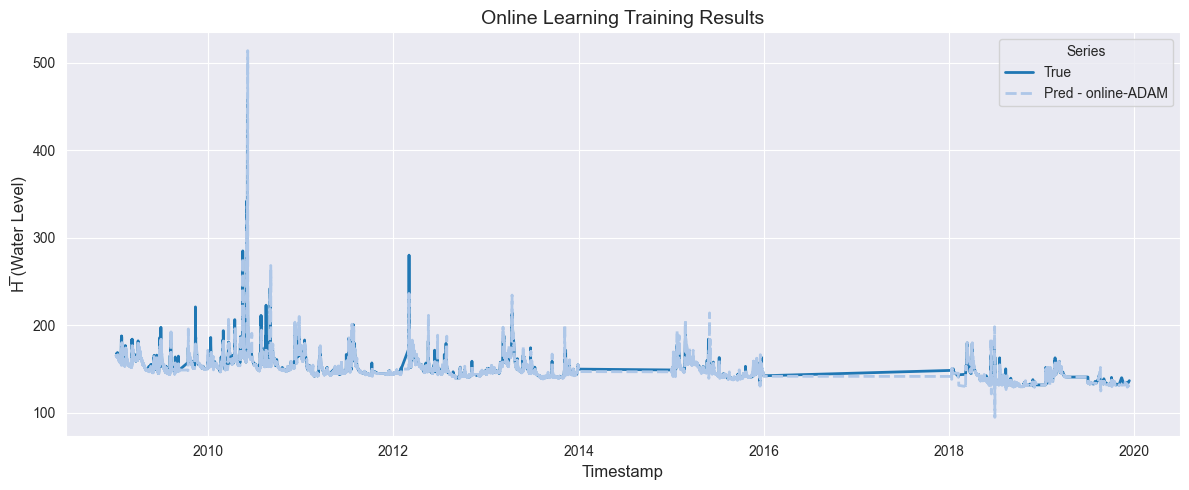

Appended metrics to CSV: results/training\Online Learning Training Results.csv


In [7]:
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              train_ds, train_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-ADAM": (y_true, y_pred, time_indices)}, 
                              plot_title="Online Learning Training Results",
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/training/Online Learning Training Results')

Testing complete.


============== FINAL COMPARISON ==============
online-ADAM          | RMSE=5.1237 | MAE=1.4171 | R²=0.7923


Saved PNG: results/testing/online\Online Learning MLP test.png


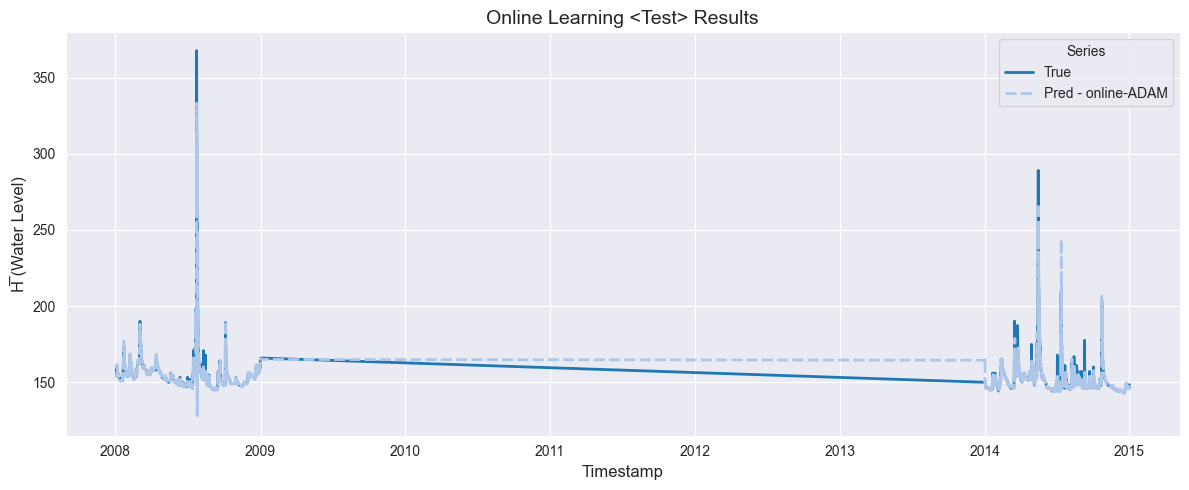

Appended metrics to CSV: results/testing/online\Online Learning MLP test.csv
Exported results to CSV: results/testing/predictions_vs_true/online_MLP.csv


In [8]:
# evaluation on test set
y_true_test, y_pred_test, time_indices_test = uf.model_evaluate_with_norm(model,criterion, test_ds, test_df.index,
                                                                 LOOKBACK, HORIZON, BATCH_SIZE)
uf.calculate_metrics_and_plot({"online-ADAM": (y_true_test, y_pred_test, time_indices_test)},
                              plot_title = 'Online Learning <Test> Results',
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/testing/online/Online Learning MLP test')
# Save predictions to CSV files to be used later in Experiments
uf.export_results_to_csv({"MLP": (y_true_test, y_pred_test,time_indices_test)}, 
                         "results/testing/predictions_vs_true/online")
    


Starting 'online' training with 821 batches...
   Batch 100/821, Loss: 0.124420
   Batch 200/821, Loss: 12.679423
   Batch 300/821, Loss: 0.008790
   Batch 400/821, Loss: 0.288055
   Batch 500/821, Loss: 1.105179
   Batch 600/821, Loss: 0.041347
   Batch 700/821, Loss: 4.935181
   Batch 800/821, Loss: 0.445055
   Batch 821/821, Loss: 0.030252
Training complete.
Testing complete.


============== FINAL COMPARISON ==============
online-ADAM s24 (original) | RMSE=5.1237 | MAE=1.4171 | R²=0.7923
online-ADAM s72 (no-leak) | RMSE=5.4855 | MAE=1.6749 | R²=0.7488


Saved PNG: results/testing/online\Online_step_comparison.png


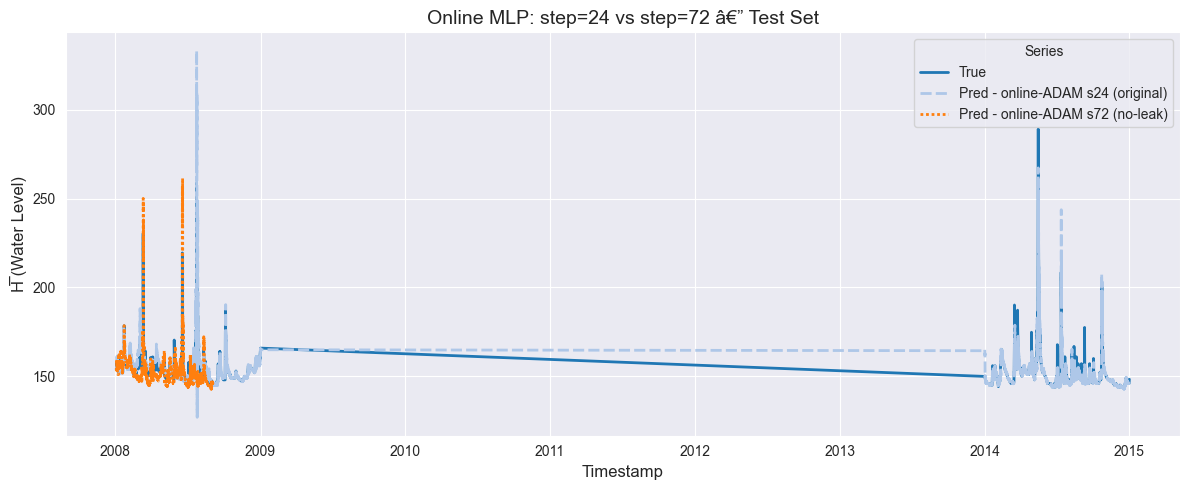

Appended metrics to CSV: results/testing/online\Online_step_comparison.csv


In [9]:
# --- Train & evaluate with step=72 (no leakage) ---
model_72, optimizer_72, criterion_72 = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true_72, y_pred_72, time_indices_72, _ = uf.train_model_online(model_72, optimizer_72, criterion_72,
                                                                   train_ds_72, train_df,
                                                                   LOOKBACK, HORIZON, BATCH_SIZE)

y_true_test_72, y_pred_test_72, time_indices_test_72 = uf.model_evaluate_with_norm(model_72, criterion_72,
                                                                                    test_ds_72, test_df.index,
                                                                                    LOOKBACK, HORIZON, BATCH_SIZE)

# --- Compare step=24 (original) vs step=72 (no leakage) on test set ---
uf.calculate_metrics_and_plot(
    {
        "online-ADAM s24 (original)": (y_true_test,    y_pred_test,    time_indices_test),
        "online-ADAM s72 (no-leak)":  (y_true_test_72, y_pred_test_72, time_indices_test_72),
    },
    plot_title="Online MLP: step=24 vs step=72 â€” Test Set",
    export_metrics=True,
    export_html=True,
    export_file_name='results/testing/online/Online_step_comparison'
)

## Testing Always updating
See model behaviour if we allowed it to learn on the fly from the testing data.<br>
**conclusion**<br>
Model's performance metrics went up as we all model to optimize and generalize more. In contarst model ability to adapt in lowered.<br>
We need to investigate more about optimizers and the adaptability, generalization trade-off.


Starting 'online' training with 728 batches...
   Batch 100/728, Loss: 20.200651
   Batch 200/728, Loss: 0.950054
   Batch 300/728, Loss: 0.083287
   Batch 400/728, Loss: 0.050103
   Batch 500/728, Loss: 0.007419
   Batch 600/728, Loss: 0.239944
   Batch 700/728, Loss: 0.069852
   Batch 728/728, Loss: 2.360912
Training complete.


============== FINAL COMPARISON ==============
online-MLP           | RMSE=5.5316 | MAE=1.8314 | R²=0.7579


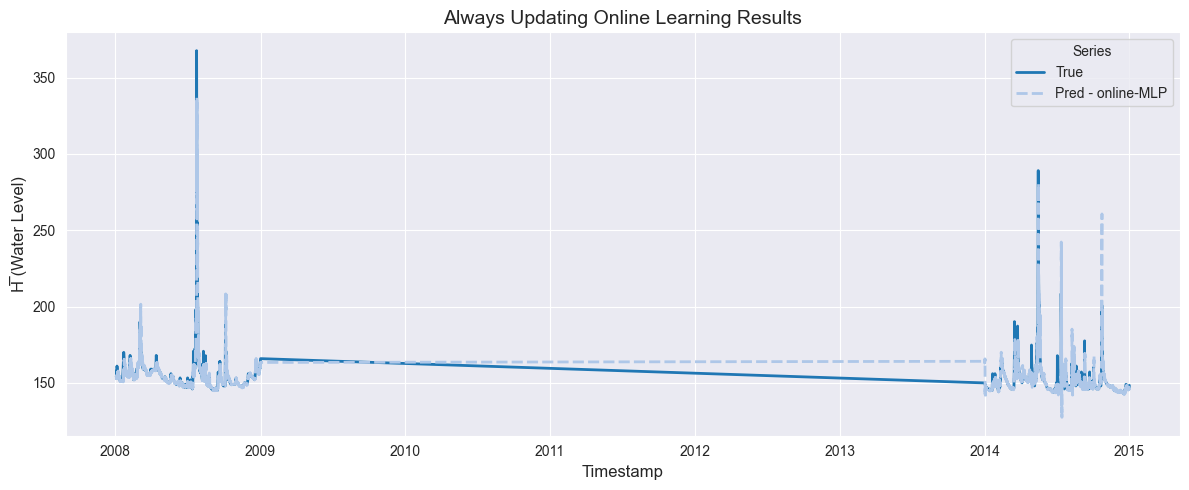

In [10]:
# Testing with always updating 
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              test_ds, test_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-MLP": (y_true, y_pred, time_indices)}, 
                              plot_title="Always Updating Online Learning Results")

# Phase 1: Normalization Experiments (Leak Fix + Stability)
> **Goal:** find the normalization that keeps `y_scaled` stable after the leak fix.
> All runs use Adam (lr=1e-3) + MLP so only the dataset class changes.

## 1.2 RollingNorm + y_clip (Leak-Fixed Baseline)


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 0.148804
   Batch 200/2461, Loss: 0.002947
   Batch 300/2461, Loss: 0.076282
   Batch 400/2461, Loss: 0.044244
   Batch 500/2461, Loss: 0.008064
   Batch 600/2461, Loss: 0.851219
   Batch 700/2461, Loss: 0.827300
   Batch 800/2461, Loss: 0.006139
   Batch 900/2461, Loss: 20.165518
   Batch 1000/2461, Loss: 0.134765
   Batch 1100/2461, Loss: 0.210135
   Batch 1200/2461, Loss: 0.291978
   Batch 1300/2461, Loss: 0.002922
   Batch 1400/2461, Loss: 0.268230
   Batch 1500/2461, Loss: 0.022266
   Batch 1600/2461, Loss: 2.377944
   Batch 1700/2461, Loss: 2.042948
   Batch 1800/2461, Loss: 0.020452
   Batch 1900/2461, Loss: 4.409785
   Batch 2000/2461, Loss: 0.156654
   Batch 2100/2461, Loss: 0.546952
   Batch 2200/2461, Loss: 0.149324
   Batch 2300/2461, Loss: 0.317937
   Batch 2400/2461, Loss: 0.226286
   Batch 2461/2461, Loss: 0.013510
Training complete.


============== FINAL COMPARISON ==============
RollingNorm+clip

Saved PNG: results/training/online\p1_rolling_clip.png


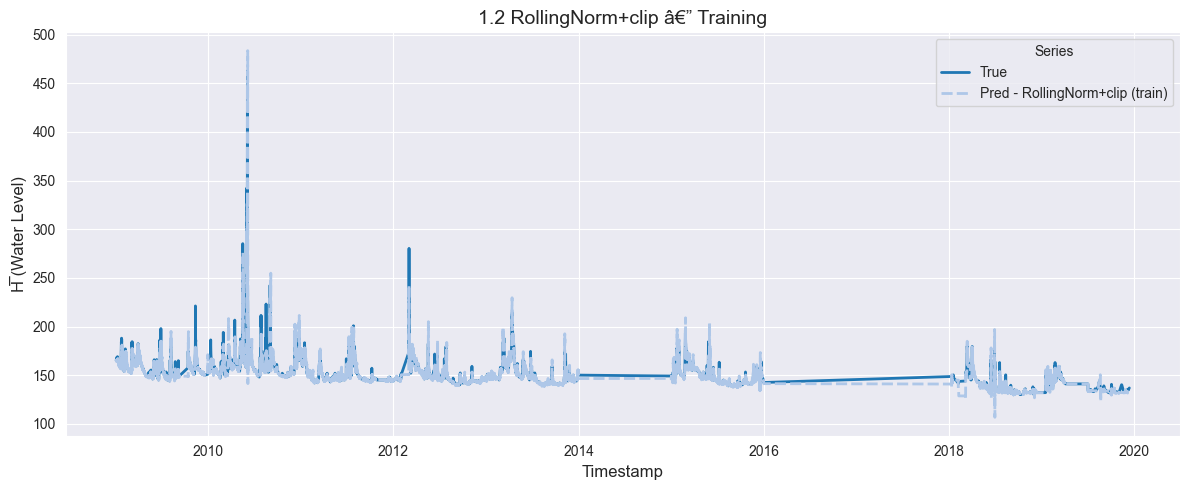

Appended metrics to CSV: results/training/online\p1_rolling_clip.csv


In [11]:
import torch
torch.manual_seed(42)

# RollingNorm with y_scaled clamped to [-5, 5] â€” leak fixed, same Adam baseline
train_ds_roll = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX, y_clip=5.0)
test_ds_roll  = uf.RollingNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX, y_clip=5.0)

model_roll, opt_roll, crit_roll = build_mlp(LOOKBACK * N_FEATURES, HORIZON)

y_tr_roll, y_pr_roll, idx_roll, losses_roll = uf.train_model_online(
    model_roll, opt_roll, crit_roll,
    train_ds_roll, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
)

uf.calculate_metrics_and_plot(
    {"RollingNorm+clip (train)": (y_tr_roll, y_pr_roll, idx_roll)},
    plot_title="1.2 RollingNorm+clip â€” Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p1_rolling_clip",
)

Testing complete.


============== FINAL COMPARISON ==============
RollingNorm+clip     | RMSE=5.0762 | MAE=1.4829 | R²=0.7961


Saved PNG: results/testing/online\p1_rolling_clip.png


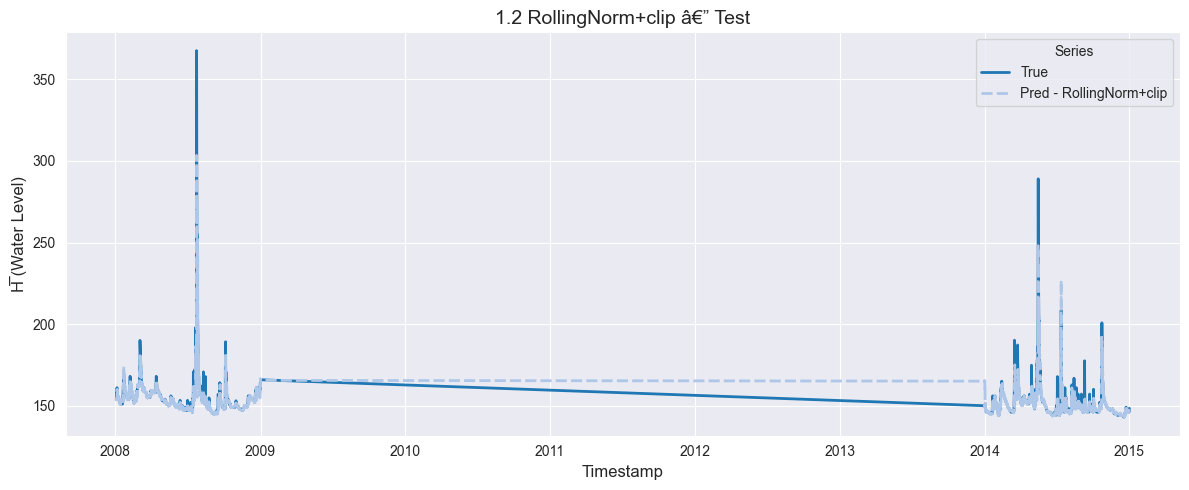

Appended metrics to CSV: results/testing/online\p1_rolling_clip.csv
Exported results to CSV: results/testing/predictions_vs_true/online_RollingNorm_clip.csv


In [12]:
y_te_roll, y_pe_roll, idx_te_roll = uf.model_evaluate_with_norm(
    model_roll, crit_roll, test_ds_roll, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)

uf.calculate_metrics_and_plot(
    {"RollingNorm+clip": (y_te_roll, y_pe_roll, idx_te_roll)},
    plot_title="1.2 RollingNorm+clip â€” Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p1_rolling_clip",
)
uf.export_results_to_csv(
    {"RollingNorm_clip": (y_te_roll, y_pe_roll, idx_te_roll)},
    "results/testing/predictions_vs_true/online"
)

## 1.3: ZScore Normalization + Adam


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 14.791898
   Batch 200/2461, Loss: 0.088763
   Batch 300/2461, Loss: 1.421784
   Batch 400/2461, Loss: 0.196778
   Batch 500/2461, Loss: 0.408490
   Batch 600/2461, Loss: 2.841714
   Batch 700/2461, Loss: 452.933014
   Batch 800/2461, Loss: 5.990421
   Batch 900/2461, Loss: 8958.837891
   Batch 1000/2461, Loss: 183.775085
   Batch 1100/2461, Loss: 302.401062
   Batch 1200/2461, Loss: 2.030922
   Batch 1300/2461, Loss: 5.047127
   Batch 1400/2461, Loss: 44.248722
   Batch 1500/2461, Loss: 195.947678
   Batch 1600/2461, Loss: 772.352112
   Batch 1700/2461, Loss: 939.175110
   Batch 1800/2461, Loss: 1398.938843
   Batch 1900/2461, Loss: 194949021696.000000
   Batch 2000/2461, Loss: 60.185654
   Batch 2100/2461, Loss: 544.941833
   Batch 2200/2461, Loss: 458.352386
   Batch 2300/2461, Loss: 37.665932
   Batch 2400/2461, Loss: 19.366167
   Batch 2461/2461, Loss: 1.230508
Training complete.


============== FINAL COMPA

Saved PNG: results/training/online\p1_zscore.png


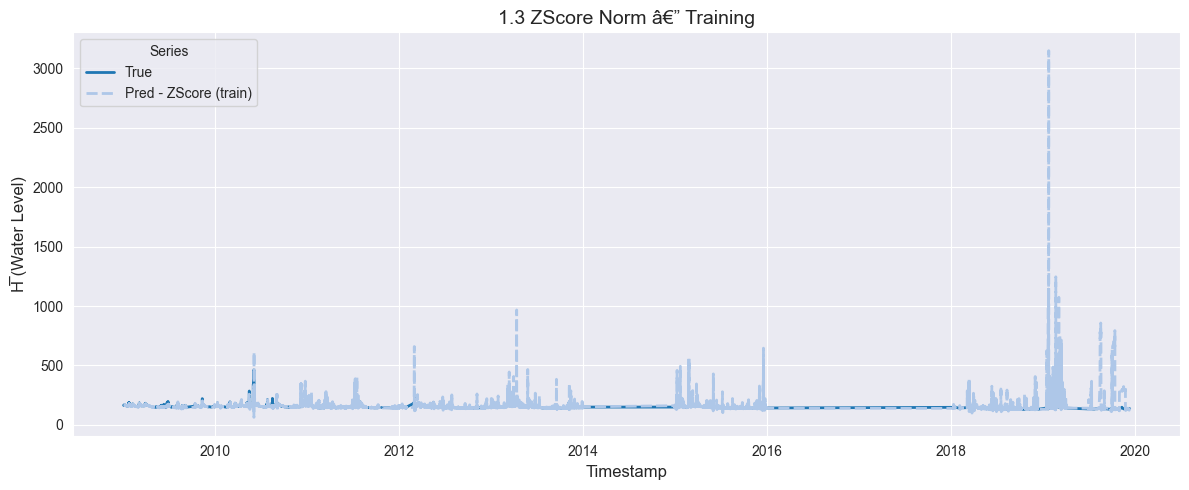

Appended metrics to CSV: results/training/online\p1_zscore.csv


In [13]:
torch.manual_seed(42)

train_ds_zscore = uf.ZScoreNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds_zscore  = uf.ZScoreNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX)

model_zs, opt_zs, crit_zs = build_mlp(LOOKBACK * N_FEATURES, HORIZON)

y_tr_zs, y_pr_zs, idx_zs, losses_zs = uf.train_model_online(
    model_zs, opt_zs, crit_zs,
    train_ds_zscore, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
)

uf.calculate_metrics_and_plot(
    {"ZScore (train)": (y_tr_zs, y_pr_zs, idx_zs)},
    plot_title="1.3 ZScore Norm â€” Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p1_zscore",
)

Testing complete.


============== FINAL COMPARISON ==============
ZScore               | RMSE=306.8214 | MAE=83.9808 | R²=-711.2254


Saved PNG: results/testing/online\p1_zscore.png


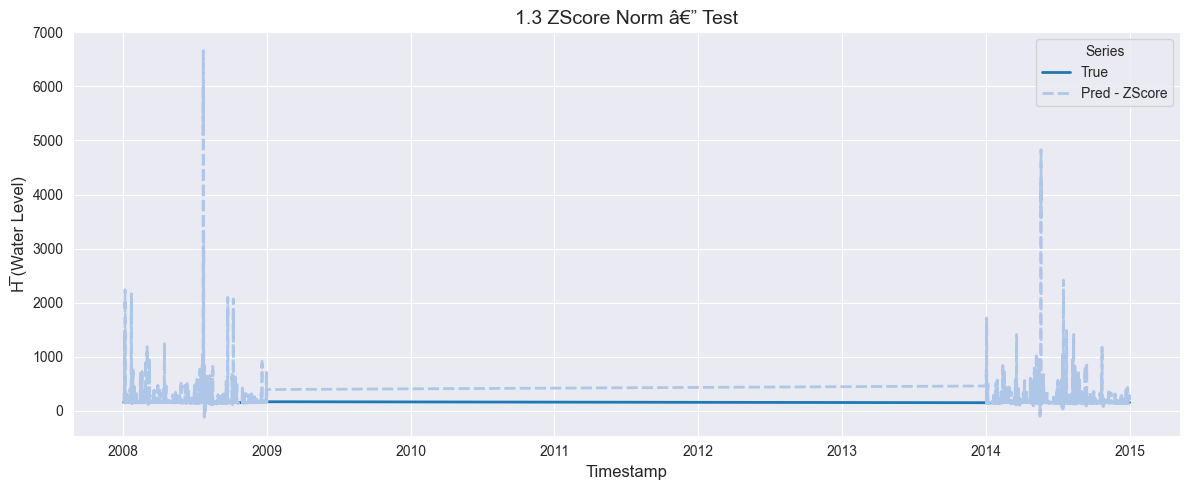

Appended metrics to CSV: results/testing/online\p1_zscore.csv
Exported results to CSV: results/testing/predictions_vs_true/online_ZScore.csv


In [ ]:
y_te_zs, y_pe_zs, idx_te_zs = uf.model_evaluate_with_norm(
    model_zs, crit_zs, test_ds_zscore, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)

uf.calculate_metrics_and_plot(
    {"ZScore": (y_te_zs, y_pe_zs, idx_te_zs)},
    plot_title="1.3 ZScore Norm” Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p1_zscore",
)
uf.export_results_to_csv(
    {"ZScore": (y_te_zs, y_pe_zs, idx_te_zs)},
    "results/testing/predictions_vs_true/online"
)

## 1.1 : Percentile Norm (5th/95th) + Adam


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 15.155770
   Batch 200/2461, Loss: 0.064556
   Batch 300/2461, Loss: 0.028606
   Batch 400/2461, Loss: 0.053448
   Batch 500/2461, Loss: 0.061187
   Batch 600/2461, Loss: 1.000817
   Batch 700/2461, Loss: 0.577742
   Batch 800/2461, Loss: 0.045292
   Batch 900/2461, Loss: 3979.014404
   Batch 1000/2461, Loss: 0.322428
   Batch 1100/2461, Loss: 2.778554
   Batch 1200/2461, Loss: 0.230297
   Batch 1300/2461, Loss: 0.028935
   Batch 1400/2461, Loss: 0.217905
   Batch 1500/2461, Loss: 0.027012
   Batch 1600/2461, Loss: 12.595590
   Batch 1700/2461, Loss: 3.212442
   Batch 1800/2461, Loss: 1.260683
   Batch 1900/2461, Loss: 5.103719
   Batch 2000/2461, Loss: 0.066992
   Batch 2100/2461, Loss: 0.424829
   Batch 2200/2461, Loss: 0.074591
   Batch 2300/2461, Loss: 0.425085
   Batch 2400/2461, Loss: 0.255101
   Batch 2461/2461, Loss: 0.043374
Training complete.


============== FINAL COMPARISON ==============
Percentile (

Saved PNG: results/training/online\p1_percentile.png


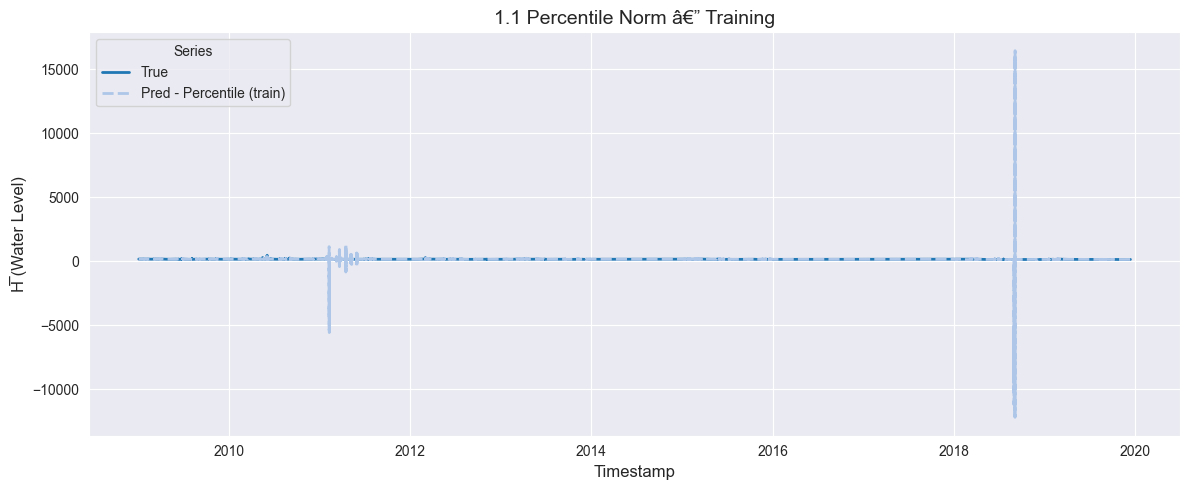

Appended metrics to CSV: results/training/online\p1_percentile.csv


In [ ]:
torch.manual_seed(42)

train_ds_pct = uf.PercentileNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX, y_clip=5.0)
test_ds_pct  = uf.PercentileNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX, y_clip=5.0)

model_pct, opt_pct, crit_pct = build_mlp(LOOKBACK * N_FEATURES, HORIZON)

y_tr_pct, y_pr_pct, idx_pct, losses_pct = uf.train_model_online(
    model_pct, opt_pct, crit_pct,
    train_ds_pct, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
)

uf.calculate_metrics_and_plot(
    {"Percentile (train)": (y_tr_pct, y_pr_pct, idx_pct)},
    plot_title="1.1 Percentile Norm” Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p1_percentile",
)

Testing complete.


============== FINAL COMPARISON ==============
Percentile           | RMSE=6.1968 | MAE=1.8588 | R²=0.6936


Saved PNG: results/testing/online\p1_percentile.png


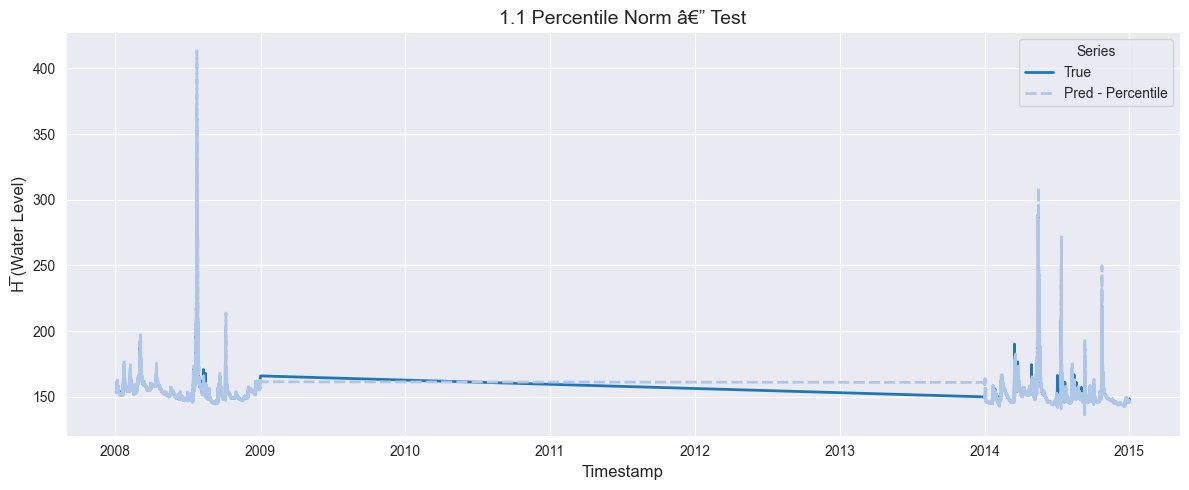

Appended metrics to CSV: results/testing/online\p1_percentile.csv
Exported results to CSV: results/testing/predictions_vs_true/online_Percentile.csv


In [ ]:
y_te_pct, y_pe_pct, idx_te_pct = uf.model_evaluate_with_norm(
    model_pct, crit_pct, test_ds_pct, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)

uf.calculate_metrics_and_plot(
    {"Percentile": (y_te_pct, y_pe_pct, idx_te_pct)},
    plot_title="1.1 Percentile Norm” Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p1_percentile",
)
uf.export_results_to_csv(
    {"Percentile": (y_te_pct, y_pe_pct, idx_te_pct)},
    "results/testing/predictions_vs_true/online"
)

## Phase 1 Summary” All Normalisations vs Test Set



============== FINAL COMPARISON ==============
RollingNorm+clip     | RMSE=5.0762 | MAE=1.4829 | R²=0.7961
ZScore               | RMSE=306.8214 | MAE=83.9808 | R²=-711.2254
Percentile           | RMSE=6.1968 | MAE=1.8588 | R²=0.6936


Saved PNG: results/testing/online\phase1_norm_comparison.png


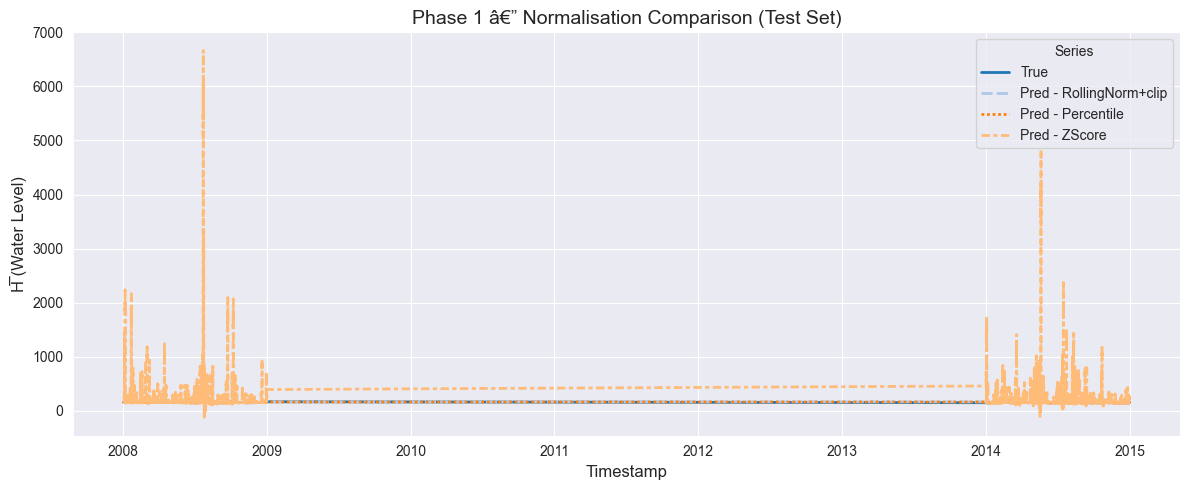

Appended metrics to CSV: results/testing/online\phase1_norm_comparison.csv


In [ ]:
uf.calculate_metrics_and_plot(
    {
        "RollingNorm+clip": (y_te_roll, y_pe_roll, idx_te_roll),
        "ZScore":           (y_te_zs,   y_pe_zs,   idx_te_zs),
        "Percentile":       (y_te_pct,  y_pe_pct,  idx_te_pct),
    },
    plot_title="Phase” Normalisation Comparison (Test Set)",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/phase1_norm_comparison",
)

# Phase 2: Optimizer Experiments
> Uses the **best normalization from Phase 1** (swap `BEST_TRAIN_DS` / `BEST_TEST_DS` below).
> All other params fixed. Each cell is self-contained â€” run independently.

In [18]:
# Set this to the winner from Phase 1 before running Phase 2 â”€â”€
BEST_TRAIN_DS = train_ds_zscore   # e.g. train_ds_roll / train_ds_zscore / train_ds_pct
BEST_TEST_DS  = test_ds_zscore    # matching test dataset

## 2.1 : RMSprop


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 15.051643
   Batch 200/2461, Loss: 0.014027
   Batch 300/2461, Loss: 0.226771
   Batch 400/2461, Loss: 0.166085
   Batch 500/2461, Loss: 0.760752
   Batch 600/2461, Loss: 0.103462
   Batch 700/2461, Loss: 3.738677
   Batch 800/2461, Loss: 0.363881
   Batch 900/2461, Loss: 7545.957031
   Batch 1000/2461, Loss: 2.837109
   Batch 1100/2461, Loss: 3.703171
   Batch 1200/2461, Loss: 1.150348
   Batch 1300/2461, Loss: 0.046513
   Batch 1400/2461, Loss: 1.055102
   Batch 1500/2461, Loss: 1.430368
   Batch 1600/2461, Loss: 119.621727
   Batch 1700/2461, Loss: 147.603683
   Batch 1800/2461, Loss: 0.353251
   Batch 1900/2461, Loss: 194950332416.000000
   Batch 2000/2461, Loss: 1.727617
   Batch 2100/2461, Loss: 12.570312
   Batch 2200/2461, Loss: 1.142321
   Batch 2300/2461, Loss: 0.039770
   Batch 2400/2461, Loss: 0.091089
   Batch 2461/2461, Loss: 1.295315
Training complete.


============== FINAL COMPARISON ============

Saved PNG: results/training/online\p2_rmsprop.png


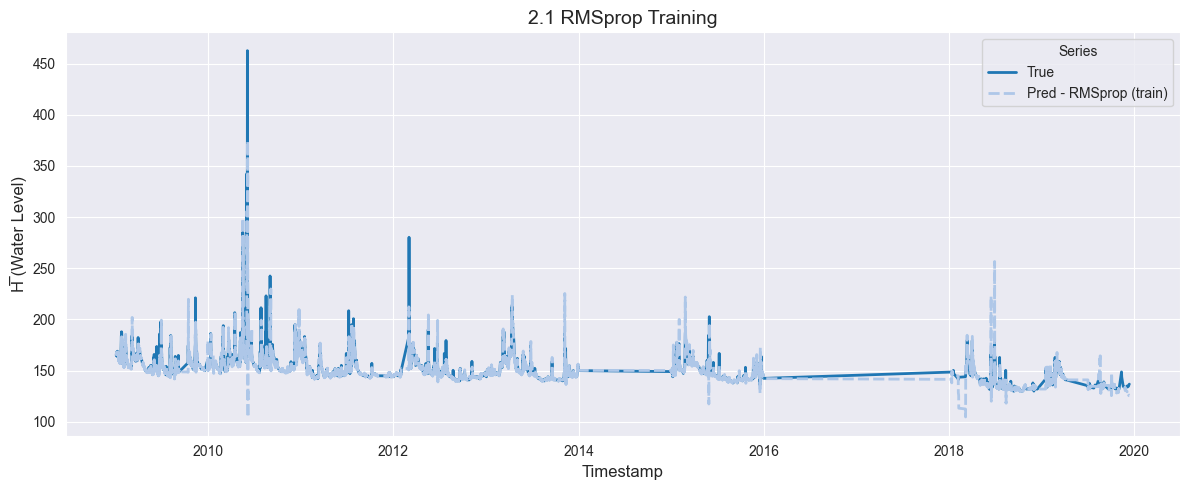

Appended metrics to CSV: results/training/online\p2_rmsprop.csv


In [19]:
import torch.optim as optim
torch.manual_seed(42)

model_rms, _, crit_rms = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
opt_rms = optim.RMSprop(model_rms.parameters(), lr=1e-3, alpha=0.99)

y_tr_rms, y_pr_rms, idx_rms, losses_rms = uf.train_model_online(
    model_rms, opt_rms, crit_rms,
    BEST_TRAIN_DS, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0,
)

uf.calculate_metrics_and_plot(
    {"RMSprop (train)": (y_tr_rms, y_pr_rms, idx_rms)},
    plot_title="2.1 RMSprop Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p2_rmsprop",
)

Testing complete.


============== FINAL COMPARISON ==============
RMSprop              | RMSE=6.7286 | MAE=1.7934 | R²=0.6575


Saved PNG: results/testing/online\p2_rmsprop.png


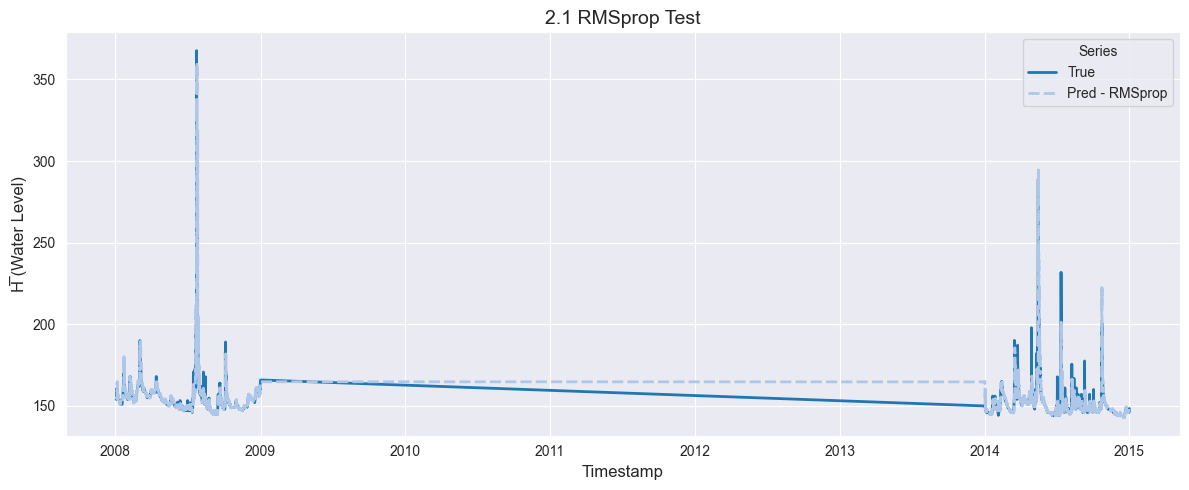

Appended metrics to CSV: results/testing/online\p2_rmsprop.csv
Exported results to CSV: results/testing/predictions_vs_true/online_RMSprop.csv


In [20]:
y_te_rms, y_pe_rms, idx_te_rms = uf.model_evaluate_with_norm(
    model_rms, crit_rms, BEST_TEST_DS, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)
uf.calculate_metrics_and_plot(
    {"RMSprop": (y_te_rms, y_pe_rms, idx_te_rms)},
    plot_title="2.1 RMSprop Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p2_rmsprop",
)
uf.export_results_to_csv(
    {"RMSprop": (y_te_rms, y_pe_rms, idx_te_rms)},
    "results/testing/predictions_vs_true/online"
)

## 2.2 : SGD + Momentum (+ Nesterov)


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 11.787366
   Batch 200/2461, Loss: 0.222636
   Batch 300/2461, Loss: 0.079567
   Batch 400/2461, Loss: 0.459875
   Batch 500/2461, Loss: 0.347282
   Batch 600/2461, Loss: 0.023398
   Batch 700/2461, Loss: 4.177991
   Batch 800/2461, Loss: 0.586864
   Batch 900/2461, Loss: 7446.583496
   Batch 1000/2461, Loss: 3.521658
   Batch 1100/2461, Loss: 4.779443
   Batch 1200/2461, Loss: 0.952896
   Batch 1300/2461, Loss: 0.141228
   Batch 1400/2461, Loss: 2.201981
   Batch 1500/2461, Loss: 0.818212
   Batch 1600/2461, Loss: 128.197784
   Batch 1700/2461, Loss: 129.591690
   Batch 1800/2461, Loss: 0.336443
   Batch 1900/2461, Loss: 194950332416.000000
   Batch 2000/2461, Loss: 0.968761
   Batch 2100/2461, Loss: 5.437566
   Batch 2200/2461, Loss: 0.393683
   Batch 2300/2461, Loss: 0.277749
   Batch 2400/2461, Loss: 0.207763
   Batch 2461/2461, Loss: 1.566823
Training complete.


============== FINAL COMPARISON =============

Saved PNG: results/training/online\p2_sgd_momentum.png


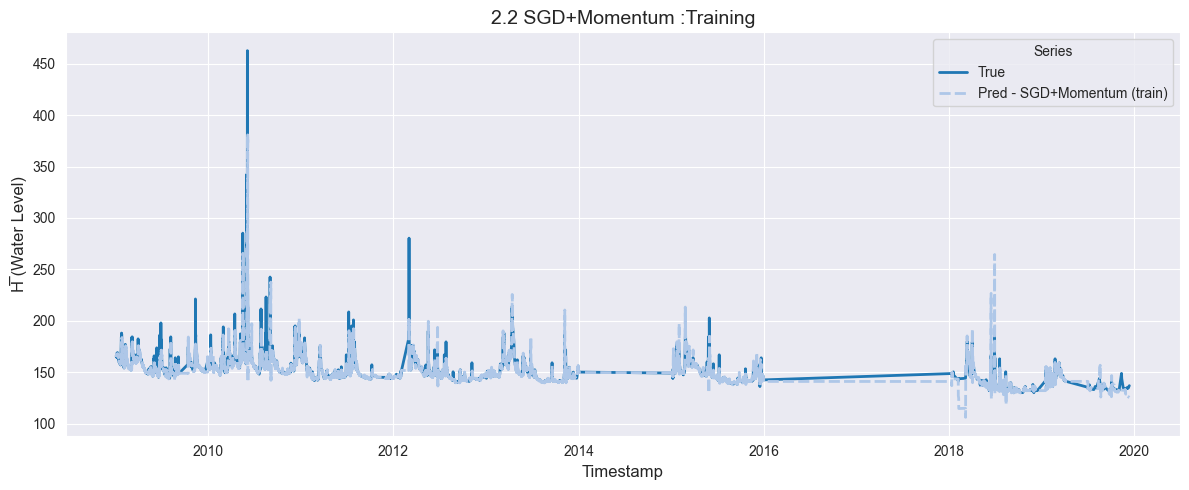

Appended metrics to CSV: results/training/online\p2_sgd_momentum.csv


In [21]:
torch.manual_seed(42)

model_sgd, _, crit_sgd = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
opt_sgd = optim.SGD(model_sgd.parameters(), lr=1e-2, momentum=0.9, nesterov=True)

y_tr_sgd, y_pr_sgd, idx_sgd, losses_sgd = uf.train_model_online(
    model_sgd, opt_sgd, crit_sgd,
    BEST_TRAIN_DS, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0,
)

uf.calculate_metrics_and_plot(
    {"SGD+Momentum (train)": (y_tr_sgd, y_pr_sgd, idx_sgd)},
    plot_title="2.2 SGD+Momentum :Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p2_sgd_momentum",
)

Testing complete.


============== FINAL COMPARISON ==============
SGD+Momentum         | RMSE=6.8855 | MAE=1.7932 | R²=0.6413


Saved PNG: results/testing/online\p2_sgd_momentum.png


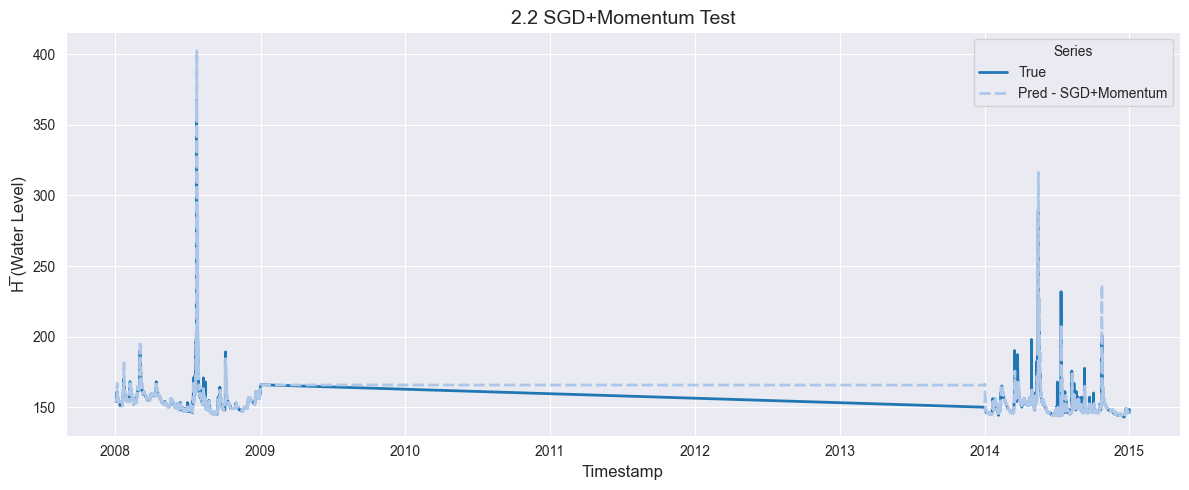

Appended metrics to CSV: results/testing/online\p2_sgd_momentum.csv
Exported results to CSV: results/testing/predictions_vs_true/online_SGD_Momentum.csv


In [22]:
y_te_sgd, y_pe_sgd, idx_te_sgd = uf.model_evaluate_with_norm(
    model_sgd, crit_sgd, BEST_TEST_DS, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)
uf.calculate_metrics_and_plot(
    {"SGD+Momentum": (y_te_sgd, y_pe_sgd, idx_te_sgd)},
    plot_title="2.2 SGD+Momentum Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p2_sgd_momentum",
)
uf.export_results_to_csv(
    {"SGD_Momentum": (y_te_sgd, y_pe_sgd, idx_te_sgd)},
    "results/testing/predictions_vs_true/online"
)

## 2.5 : Adam (low LR + weight decay)


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 28.577868
   Batch 200/2461, Loss: 1.474684
   Batch 300/2461, Loss: 3.609368
   Batch 400/2461, Loss: 1.116648
   Batch 500/2461, Loss: 0.136554
   Batch 600/2461, Loss: 0.676421
   Batch 700/2461, Loss: 2.635617
   Batch 800/2461, Loss: 0.036669
   Batch 900/2461, Loss: 7558.298828
   Batch 1000/2461, Loss: 2.460629
   Batch 1100/2461, Loss: 14.251746
   Batch 1200/2461, Loss: 2.142971
   Batch 1300/2461, Loss: 0.055074
   Batch 1400/2461, Loss: 0.829658
   Batch 1500/2461, Loss: 0.162730
   Batch 1600/2461, Loss: 215.150513
   Batch 1700/2461, Loss: 237.104507
   Batch 1800/2461, Loss: 4.798628
   Batch 1900/2461, Loss: 194950512640.000000
   Batch 2000/2461, Loss: 0.579130
   Batch 2100/2461, Loss: 1.423658
   Batch 2200/2461, Loss: 0.110182
   Batch 2300/2461, Loss: 0.498858
   Batch 2400/2461, Loss: 0.062017
   Batch 2461/2461, Loss: 0.145085
Training complete.


============== FINAL COMPARISON ============

Saved PNG: results/training/online\p2_adam_wd.png


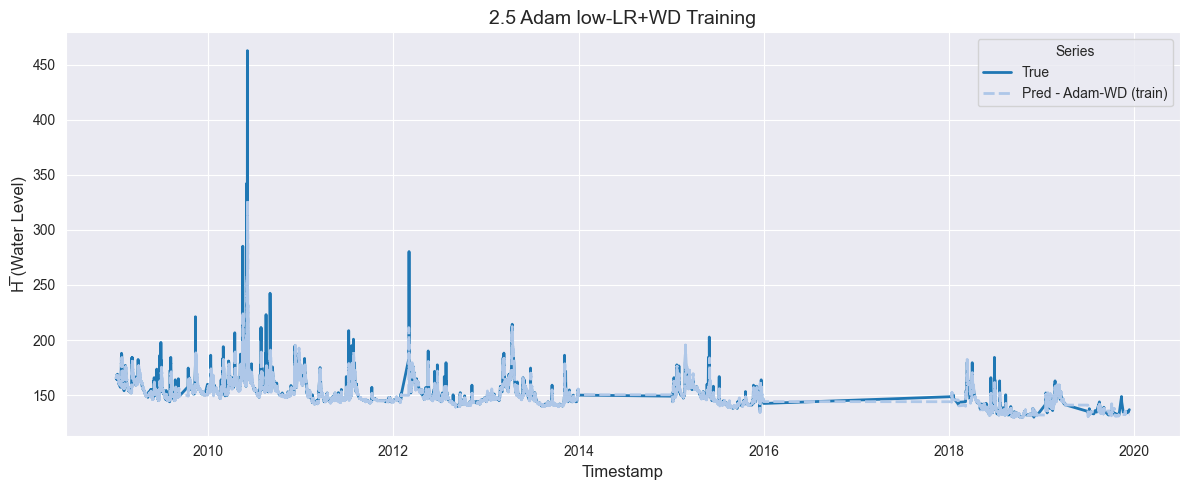

Appended metrics to CSV: results/training/online\p2_adam_wd.csv


In [23]:
torch.manual_seed(42)

model_adamwd, _, crit_adamwd = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
opt_adamwd = optim.Adam(model_adamwd.parameters(), lr=1e-4, weight_decay=1e-4)

y_tr_awd, y_pr_awd, idx_awd, losses_awd = uf.train_model_online(
    model_adamwd, opt_adamwd, crit_adamwd,
    BEST_TRAIN_DS, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0,
)

uf.calculate_metrics_and_plot(
    {"Adam-WD (train)": (y_tr_awd, y_pr_awd, idx_awd)},
    plot_title="2.5 Adam low-LR+WD Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p2_adam_wd",
)

Testing complete.


============== FINAL COMPARISON ==============
Adam-WD              | RMSE=5.2012 | MAE=1.3342 | R²=0.7953


Saved PNG: results/testing/online\p2_adam_wd.png


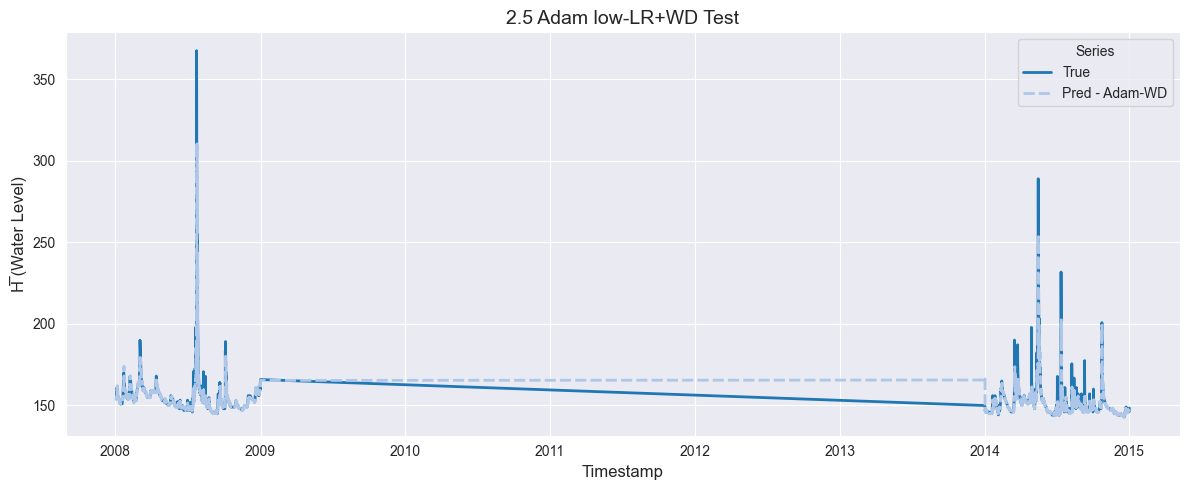

Appended metrics to CSV: results/testing/online\p2_adam_wd.csv
Exported results to CSV: results/testing/predictions_vs_true/online_Adam_WD.csv


In [24]:
y_te_awd, y_pe_awd, idx_te_awd = uf.model_evaluate_with_norm(
    model_adamwd, crit_adamwd, BEST_TEST_DS, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)
uf.calculate_metrics_and_plot(
    {"Adam-WD": (y_te_awd, y_pe_awd, idx_te_awd)},
    plot_title="2.5 Adam low-LR+WD Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p2_adam_wd",
)
uf.export_results_to_csv(
    {"Adam_WD": (y_te_awd, y_pe_awd, idx_te_awd)},
    "results/testing/predictions_vs_true/online"
)

## Phase 2 Summary of All Optimizers vs Test Set



============== FINAL COMPARISON ==============
RMSprop              | RMSE=6.7286 | MAE=1.7934 | R²=0.6575
SGD+Mom              | RMSE=6.8855 | MAE=1.7932 | R²=0.6413
Adam-WD              | RMSE=5.2012 | MAE=1.3342 | R²=0.7953


Saved PNG: results/testing/online\phase2_optimizer_comparison.png


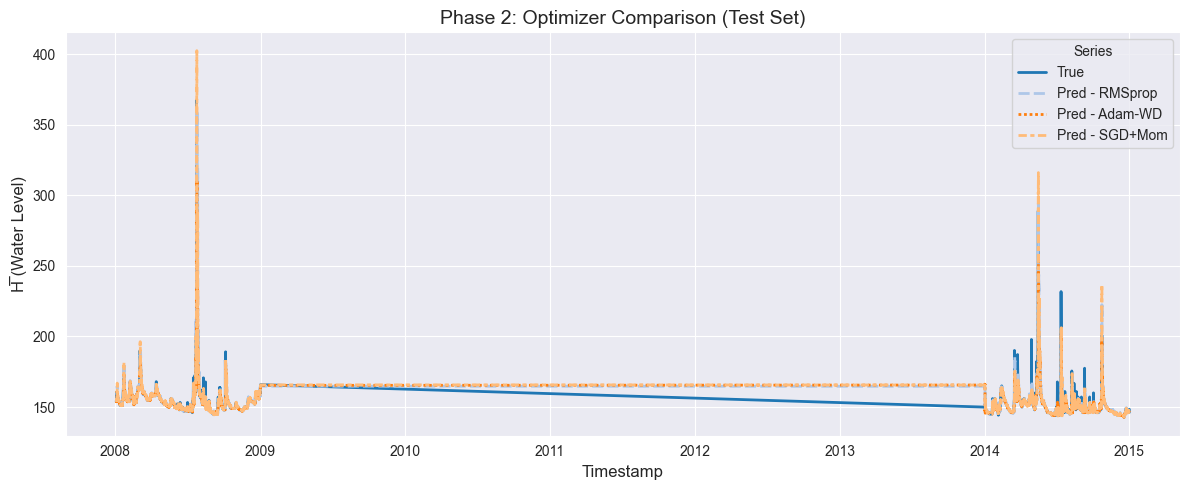

Appended metrics to CSV: results/testing/online\phase2_optimizer_comparison.csv


In [25]:
uf.calculate_metrics_and_plot(
    {
        "RMSprop":    (y_te_rms, y_pe_rms, idx_te_rms),
        "SGD+Mom":    (y_te_sgd, y_pe_sgd, idx_te_sgd),
        "Adam-WD":    (y_te_awd, y_pe_awd, idx_te_awd),
    },
    plot_title="Phase 2: Optimizer Comparison (Test Set)",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/phase2_optimizer_comparison",
)

# Phase 2b — Adam Hyperparameter Ablation
> **Fixed:** RollingNorm+clip, MLP, `max_grad_norm=1.0`
>
> | Knob | Lower | Higher |
> |---|---|---|
> | `beta1` | forgets gradients faster → better after drift | more momentum |
> | `beta2` | step size adapts faster to variance | slower adaptation |
> | `eps` | aggressive steps | conservative on calm periods |
> | `amsgrad` | — | monotone non-increasing LR (stable long-term) |

In [26]:
import importlib
import util_fun as uf
importlib.reload(uf)

ADAM_CONFIGS = [
    ("Adam-default",        dict(lr=1e-3, betas=(0.90, 0.999), eps=1e-8,  amsgrad=False)),
    ("Adam-b1=0.7",         dict(lr=1e-3, betas=(0.70, 0.999), eps=1e-8,  amsgrad=False)),
    ("Adam-b1=0.5",         dict(lr=1e-3, betas=(0.50, 0.999), eps=1e-8,  amsgrad=False)),
    ("Adam-b2=0.9",         dict(lr=1e-3, betas=(0.90, 0.900), eps=1e-8,  amsgrad=False)),
    ("Adam-eps=1e-4",       dict(lr=1e-3, betas=(0.90, 0.999), eps=1e-4,  amsgrad=False)),
    ("Adam-amsgrad",        dict(lr=1e-3, betas=(0.90, 0.999), eps=1e-8,  amsgrad=True)),
    ("Adam-b1=0.5-amsgrad", dict(lr=1e-3, betas=(0.50, 0.900), eps=1e-4,  amsgrad=True)),
    ("Adam-WD",             dict(lr=1e-4, betas=(0.90, 0.999), eps=1e-8,  amsgrad=False, weight_decay=1e-4)),
]

adam_test_results = {}
for label, kwargs in ADAM_CONFIGS:
    print(f"Running {label}...", end=" ", flush=True)
    torch.manual_seed(42)
    model_a, _, crit_a = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
    opt_a = optim.Adam(model_a.parameters(), **kwargs)

    uf.train_model_online(
        model_a, opt_a, crit_a,
        train_ds_roll, train_df,
        LOOKBACK, HORIZON, BATCH_SIZE,
        max_grad_norm=1.0, silent=True,
    )
    y_te_a, y_pe_a, idx_te_a = uf.model_evaluate_with_norm(
        model_a, crit_a, test_ds_roll, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
    )
    adam_test_results[label] = (y_te_a, y_pe_a, idx_te_a)
    uf.export_results_to_csv({label: (y_te_a, y_pe_a, idx_te_a)},
                             "results/testing/predictions_vs_true/online")
    print("done.")

print("\nAll Adam configs done.")

Running Adam-default... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-default.csv
done.
Running Adam-b1=0.7... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b1=0.7.csv
done.
Running Adam-b1=0.5... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b1=0.5.csv
done.
Running Adam-b2=0.9... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b2=0.9.csv
done.
Running Adam-eps=1e-4... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-eps=1e-4.csv
done.
Running Adam-amsgrad... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-amsgrad.csv
done.
Running Adam-b1=0.5-amsgrad... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b1=0.5-amsgrad.csv
done.
Running Adam-WD... Testing complete.
Exported results to CS



============== FINAL COMPARISON ==============
Adam-default         | RMSE=5.2011 | MAE=1.4503 | R²=0.7860
Adam-b1=0.7          | RMSE=4.6502 | MAE=1.3014 | R²=0.8289
Adam-b1=0.5          | RMSE=4.8550 | MAE=1.3437 | R²=0.8135
Adam-b2=0.9          | RMSE=5.2831 | MAE=1.4560 | R²=0.7792
Adam-eps=1e-4        | RMSE=5.2494 | MAE=1.5031 | R²=0.7820
Adam-amsgrad         | RMSE=5.4508 | MAE=1.5329 | R²=0.7649
Adam-b1=0.5-amsgrad  | RMSE=5.2031 | MAE=1.3800 | R²=0.7858
Adam-WD              | RMSE=5.1481 | MAE=1.3064 | R²=0.7903


Saved PNG: results/testing/online\phase2b_adam_ablation.png


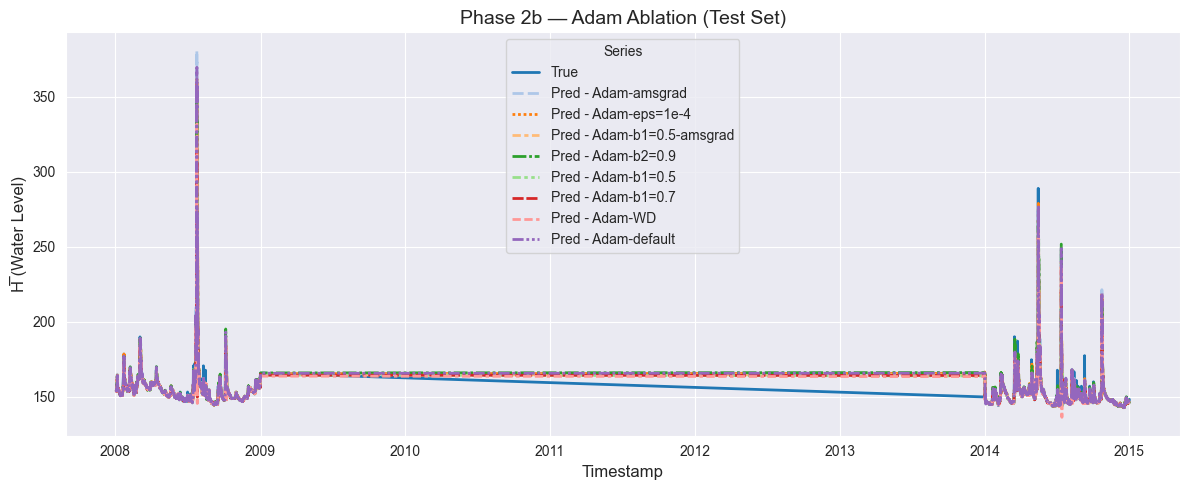

Appended metrics to CSV: results/testing/online\phase2b_adam_ablation.csv


In [27]:
uf.calculate_metrics_and_plot(
    adam_test_results,
    plot_title="Phase 2b — Adam Ablation (Test Set)",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/phase2b_adam_ablation",
)

# Phase 2c — FTRL (Follow The Regularized Leader)
> Custom PyTorch implementation in `cstm_models/ftrl.py`.
> Per-coordinate adaptive LR with L1/L2 built in — best theoretical online regret bounds.
>
> | Param | Role |
> |---|---|
> | `alpha` | Base learning rate |
> | `beta` | Smoothing — controls early-step LR (high β → conservative start) |
> | `lambda1` | L1 penalty → sparsity |
> | `lambda2` | L2 penalty → weight stability |

In [28]:
from cstm_models.ftrl import FTRL

FTRL_CONFIGS = [
    ("FTRL-default",      dict(alpha=0.01, beta=1.0, lambda1=0.0,   lambda2=0.0)),
    ("FTRL-l2=0.01",      dict(alpha=0.01, beta=1.0, lambda1=0.0,   lambda2=0.01)),
    ("FTRL-l1+l2",        dict(alpha=0.01, beta=1.0, lambda1=0.001, lambda2=0.01)),
    ("FTRL-alpha=0.1",    dict(alpha=0.1,  beta=1.0, lambda1=0.0,   lambda2=0.0)),
    ("FTRL-alpha=0.1-l2", dict(alpha=0.1,  beta=1.0, lambda1=0.0,   lambda2=0.01)),
]

ftrl_test_results = {}
for label, kwargs in FTRL_CONFIGS:
    print(f"Running {label}...", end=" ", flush=True)
    torch.manual_seed(42)
    model_f, _, crit_f = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
    opt_f = FTRL(model_f.parameters(), **kwargs)

    uf.train_model_online(
        model_f, opt_f, crit_f,
        train_ds_roll, train_df,
        LOOKBACK, HORIZON, BATCH_SIZE,
        max_grad_norm=1.0, silent=True,
    )
    y_te_f, y_pe_f, idx_te_f = uf.model_evaluate_with_norm(
        model_f, crit_f, test_ds_roll, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
    )
    ftrl_test_results[label] = (y_te_f, y_pe_f, idx_te_f)
    uf.export_results_to_csv({label: (y_te_f, y_pe_f, idx_te_f)},
                             "results/testing/predictions_vs_true/online")
    print("done.")

print("\nAll FTRL configs done.")

Running FTRL-default... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_FTRL-default.csv
done.
Running FTRL-l2=0.01... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_FTRL-l2=0.01.csv
done.
Running FTRL-l1+l2... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_FTRL-l1+l2.csv
done.
Running FTRL-alpha=0.1... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_FTRL-alpha=0.1.csv
done.
Running FTRL-alpha=0.1-l2... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_FTRL-alpha=0.1-l2.csv
done.

All FTRL configs done.




============== FINAL COMPARISON ==============
FTRL-default         | RMSE=7.7679 | MAE=2.4565 | R²=0.5226
FTRL-l2=0.01         | RMSE=7.7679 | MAE=2.4565 | R²=0.5226
FTRL-l1+l2           | RMSE=7.7680 | MAE=2.4565 | R²=0.5226
FTRL-alpha=0.1       | RMSE=4.7062 | MAE=1.4448 | R²=0.8248
FTRL-alpha=0.1-l2    | RMSE=4.8145 | MAE=1.4308 | R²=0.8166


Saved PNG: results/testing/online\phase2c_ftrl_ablation.png


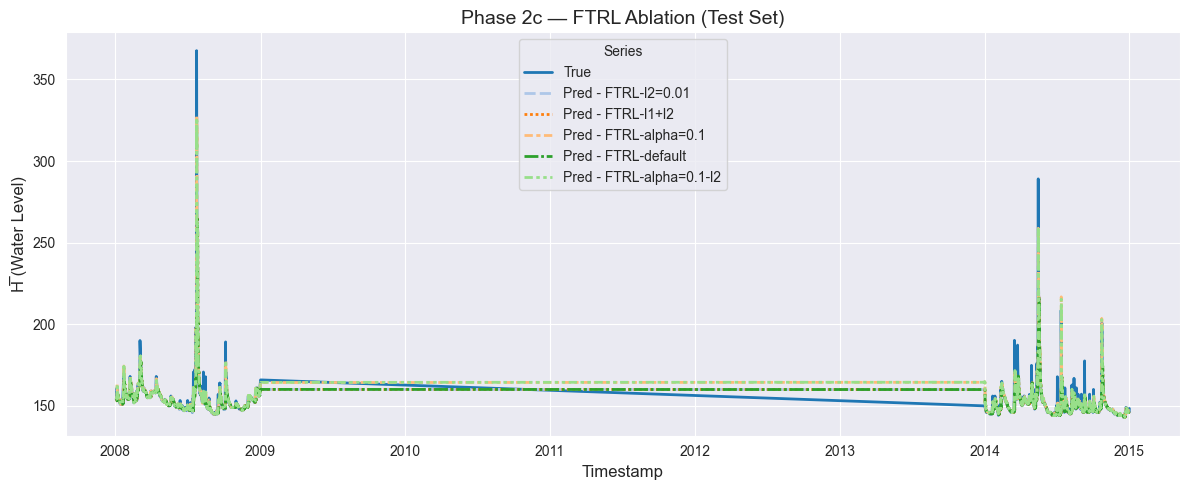

Appended metrics to CSV: results/testing/online\phase2c_ftrl_ablation.csv


In [29]:
uf.calculate_metrics_and_plot(
    ftrl_test_results,
    plot_title="Phase 2c — FTRL Ablation (Test Set)",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/phase2c_ftrl_ablation",
)

# Phase 3 — Peak Detection Analysis
> Metrics and zoom plots **restricted to flood-peak timesteps** (≥ 90th percentile of H_bar).
> Runs on the best Adam config + best FTRL config side by side.
> Update `all_peak_results` dict after Phase 2b/2c to include whichever configs you want compared.

Peak threshold (90th pct): 160.6667

Method                     Peak-RMSE   Peak-MAE  Peak-R²
---------------------------------------------------------
RollingNorm+Adam (baseline)    15.3501     7.9770   0.6088
Best-Adam (Adam-default)     15.7994     8.1822   0.5855
Best-FTRL (FTRL-alpha=0.1)    14.2708     7.8790   0.6619

Saved peak metrics: results/testing/online/peak_analysis_peak_metrics.csv

Top-5 peaks:
  2008-07-23 17:00:00  H_bar=367.6300
  2014-05-16 01:00:00  H_bar=289.0600
  2014-07-12 20:00:00  H_bar=208.5500
  2014-10-23 15:00:00  H_bar=200.7900
  2014-03-17 02:00:00  H_bar=190.1200
Saved: results/testing/online/peak_analysis_peak1.png


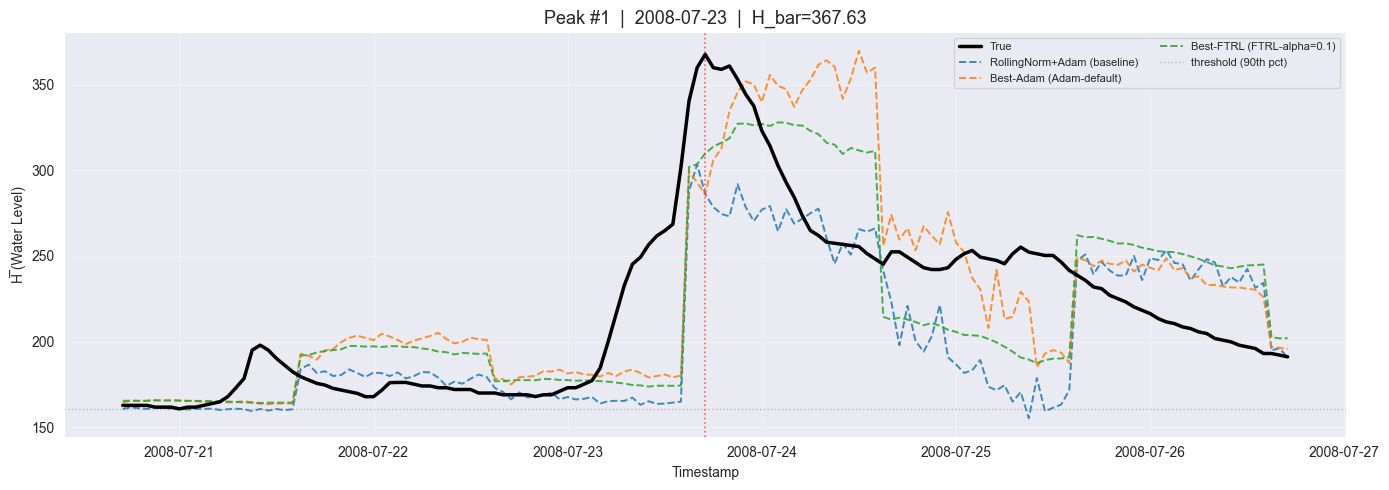

Saved: results/testing/online/peak_analysis_peak2.png


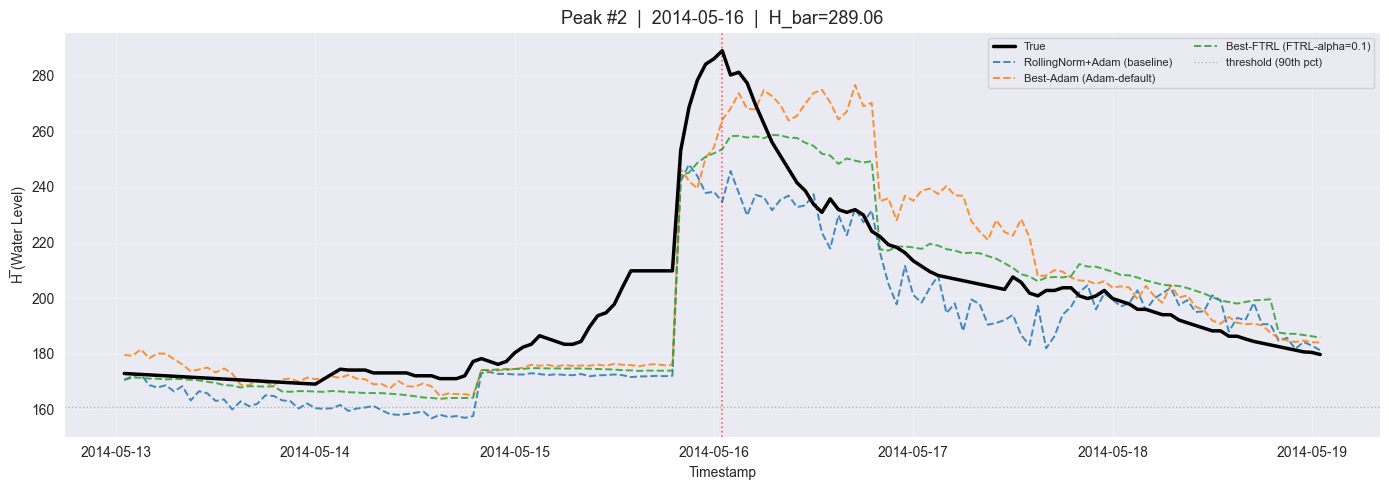

Saved: results/testing/online/peak_analysis_peak3.png


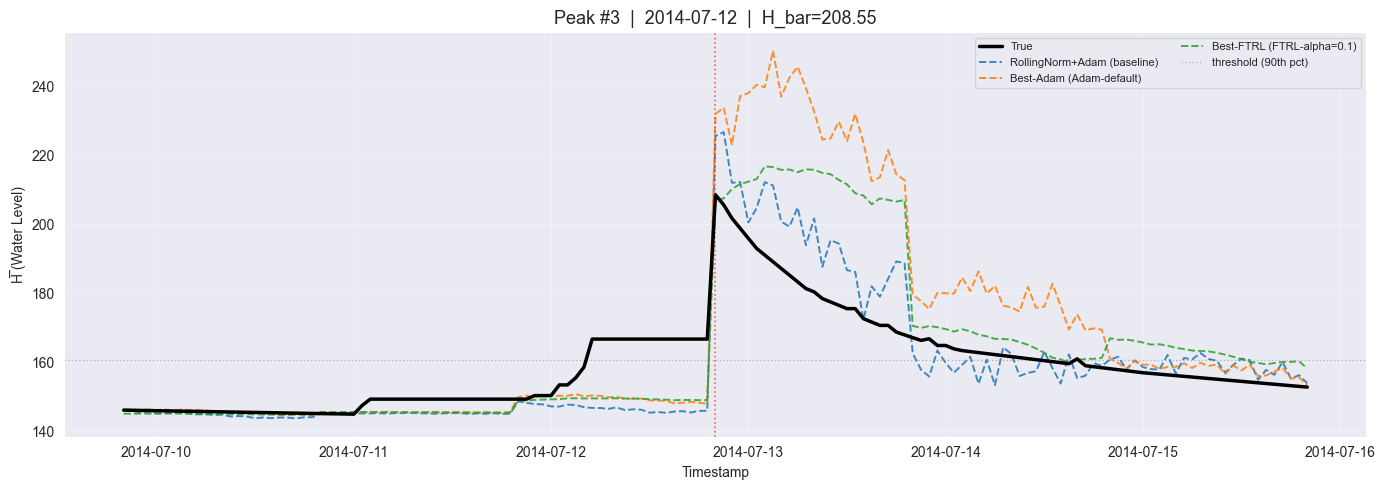

Saved: results/testing/online/peak_analysis_peak4.png


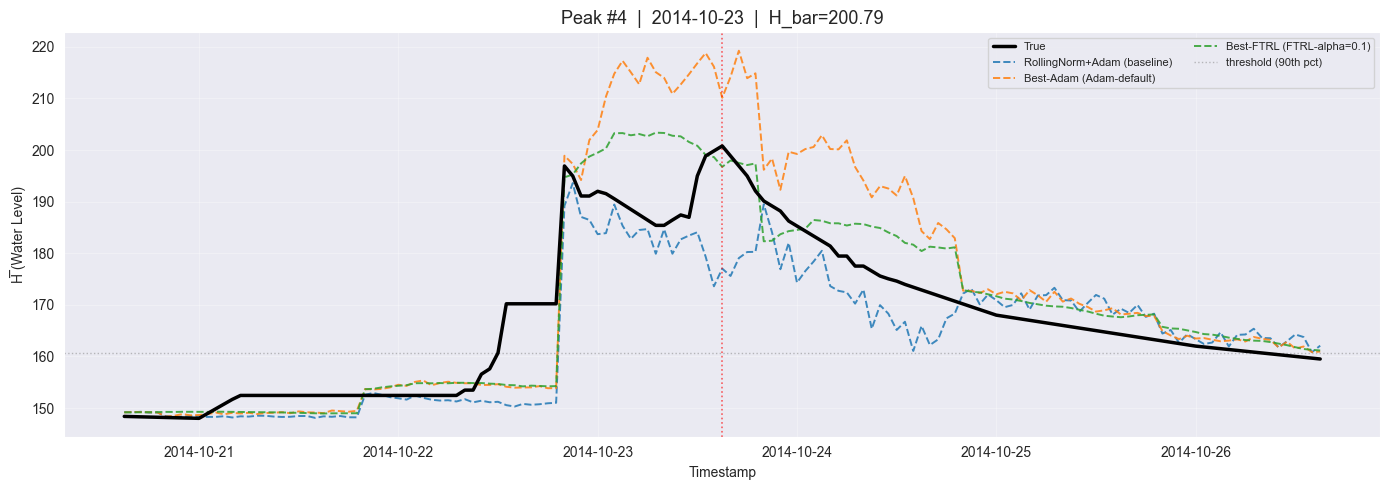

Saved: results/testing/online/peak_analysis_peak5.png


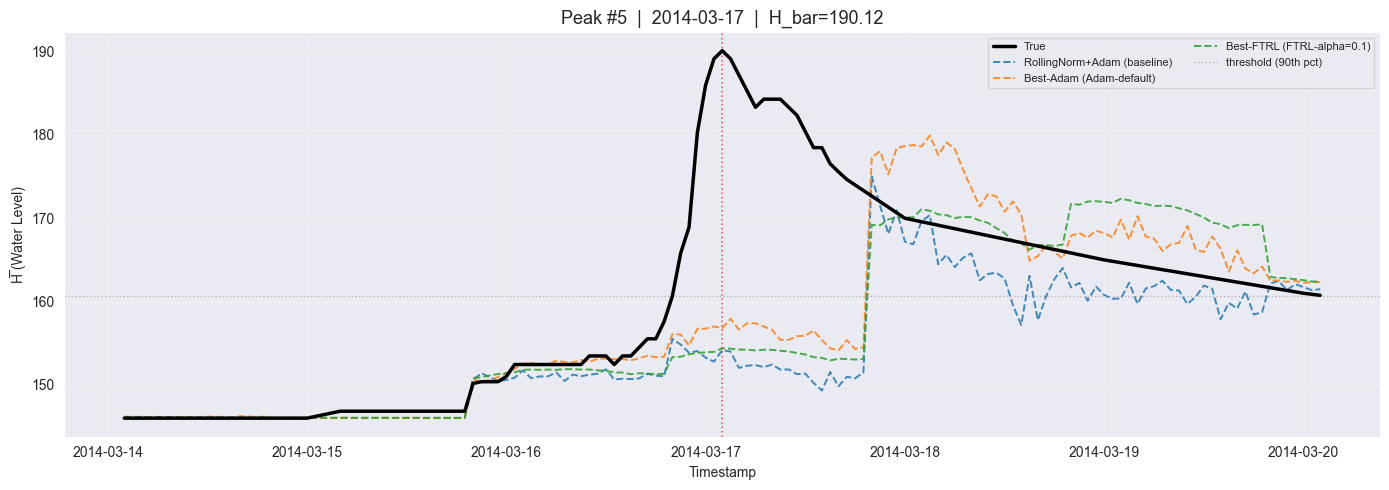

In [30]:
# ── Swap in whichever labels won Phase 2b and 2c ──────────────────────────────
BEST_ADAM_LABEL = "Adam-default"   # e.g. "Adam-b1=0.5", "Adam-amsgrad", ...
BEST_FTRL_LABEL = "FTRL-alpha=0.1" # e.g. "FTRL-l2=0.01", ...

all_peak_results = {
    "RollingNorm+Adam (baseline)": (y_te_roll, y_pe_roll, idx_te_roll),
    f"Best-Adam ({BEST_ADAM_LABEL})": adam_test_results[BEST_ADAM_LABEL],
    f"Best-FTRL ({BEST_FTRL_LABEL})": ftrl_test_results[BEST_FTRL_LABEL],
}

uf.peak_analysis(
    all_peak_results,
    peak_quantile=0.90,
    n_peaks=5,
    window_hours=72,
    export_file_name="results/testing/online/peak_analysis",
)